# End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

## Imprt libraries

In [ ]:
import os
import urllib.request
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
import ssl
import cv2

In [ ]:
!pip install -q scikit-image

In [ ]:
# Plot settings
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

## Dataset and Experimental Setup

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Original training shape:", x_train.shape)
print("Original testing shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original training shape: (60000, 28, 28)
Original testing shape: (10000, 28, 28)


In [ ]:
x_train = x_train[:10000]
x_test = x_test[:2000]

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (10000, 28, 28)
Testing shape: (2000, 28, 28)


In [ ]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
# Flatten images
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Training shape:", x_train_flat.shape)
print("Testing shape:", x_test_flat.shape)

Training shape: (10000, 784)
Testing shape: (2000, 784)


## Fully connected Autoencoder

### Parameter & Value
* Latent dimension - 16
* Optimizer - Adam
* Learning rate - 10^(-3)
* Batch size - 128
* Epochs - 20
* Loss - Binary Cross-Entropy

In [ ]:
autoencoder = models.Sequential([
    layers.Input(shape=(784,)),

    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),   # Latent representation

    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(784, activation="sigmoid")
])

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

In [ ]:
history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    batch_size=128,
    epochs=20,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.3501 - val_loss: 0.2466
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2335 - val_loss: 0.2124
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1997 - val_loss: 0.1897
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1829 - val_loss: 0.1769
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1721 - val_loss: 0.1693
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1649 - val_loss: 0.1623
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1582 - val_loss: 0.1565
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1531 - val_loss: 0.1528
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1491 - val_loss: 0.1493
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1463 - val_loss: 0.1475
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1438 - val_loss: 0.1457
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1

In [ ]:
reconstructed = autoencoder.predict(x_test_flat)

reconstructed_images = reconstructed.reshape(-1, 28, 28)

print("Reconstructed shape:", reconstructed_images.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Reconstructed shape: (2000, 28, 28)


In [ ]:
def evaluate_reconstruction(original, reconstructed):

    # Flatten images for MSE and MAE
    original_flat = original.reshape(len(original), -1)
    reconstructed_flat = reconstructed.reshape(len(reconstructed), -1)

    # MSE
    mse = mean_squared_error(
        original_flat,
        reconstructed_flat
    )

    # MAE
    mae = mean_absolute_error(
        original_flat,
        reconstructed_flat
    )

    # SSIM
    ssim_scores = []

    for i in range(len(original)):
        score = ssim(
            original[i],
            reconstructed[i],
            data_range=1.0
        )
        ssim_scores.append(score)

    mean_ssim = np.mean(ssim_scores)

    # Report results
    print("Metric              Value")
    print("--------------------------")
    print(f"Test MSE            {mse:.6f}")
    print(f"Test MAE            {mae:.6f}")
    print(f"Mean SSIM           {mean_ssim:.6f}")

    return {
        "MSE": mse,
        "MAE": mae,
        "SSIM": mean_ssim
    }

In [ ]:
fc_mse, fc_mae, fc_ssim = evaluate_reconstruction(
    x_test,
    reconstructed_images
)

Metric              Value
--------------------------
Test MSE            0.022779
Test MAE            0.059762
Mean SSIM           0.728950


In [ ]:
results = {}

results["Fully Connected AE"] = {
    "MAE": fc_mae,
    "MSE": fc_mse,
    "SSIM": fc_ssim
}

In [ ]:
def plot_original_vs_reconstructed(
    original,
    reconstructed,
    model_name,
    filename,
    n=10
):

    plt.figure(figsize=(15, 4))

    for i in range(n):

        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i], cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i], cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(
        f"{model_name}: Original vs Reconstructed",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

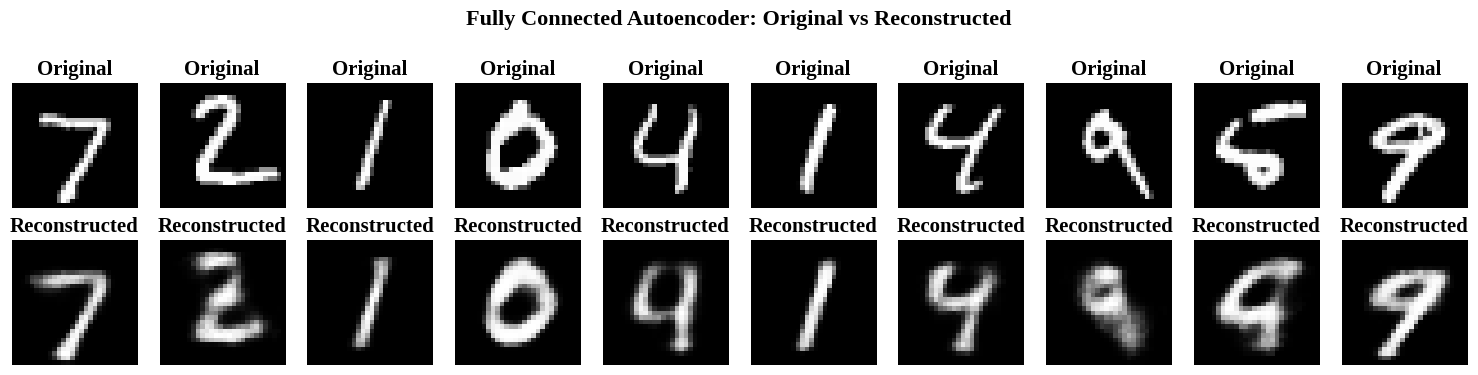

In [ ]:
plot_original_vs_reconstructed(
    x_test,
    reconstructed_images,
    "Fully Connected Autoencoder",
    "fc_ae_reconstruction",
    n=10
)

In [ ]:
def plot_train_vs_val_loss(
    history,
    model_name,
    filename
):

    epochs = np.arange(
        1,
        len(history.history["loss"]) + 1
    )

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    plt.figure(figsize=(10, 6))

    plt.plot(
        epochs,
        train_loss,
        label="Training Loss",
        linewidth=2,
        marker="o",
        markersize=5,
        markevery=2,
        color="#1f77b4"
    )

    plt.plot(
        epochs,
        val_loss,
        label="Validation Loss",
        linewidth=2,
        marker="s",
        markersize=5,
        markevery=2,
        linestyle="--",
        color="#ff7f0e"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction Loss")

    plt.title(
        f"{model_name}: Training vs Validation Loss"
    )

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

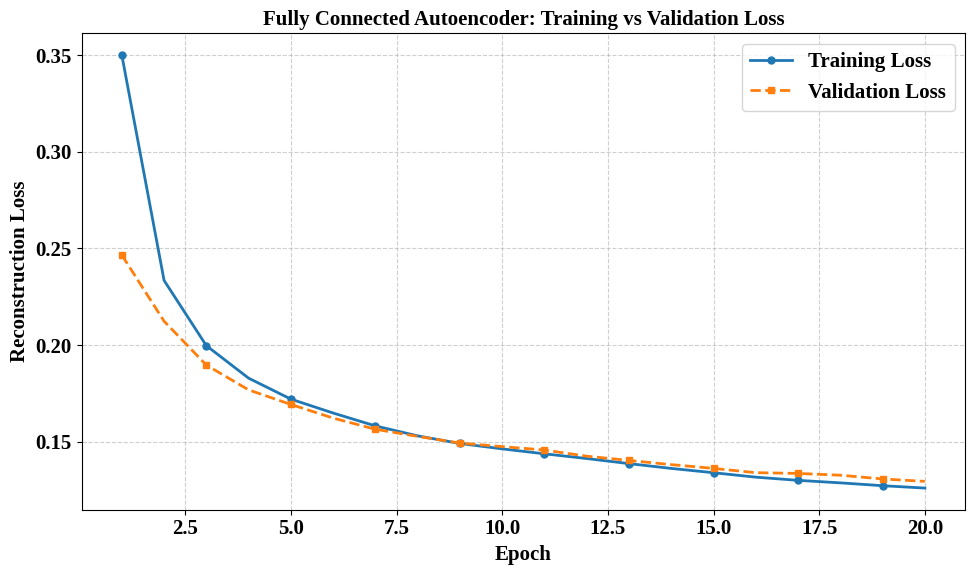

In [ ]:
plot_train_vs_val_loss(
    history,
    "Fully Connected Autoencoder",
    "fc_ae_training_validation_loss"
)

In [ ]:
def plot_reconstruction(
    original,
    reconstructed,
    model_name,
    filename,
    n=10
):

    plt.figure(figsize=(15, 6))

    for i in range(n):

        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i], cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstruction
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(reconstructed[i], cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")

        # Reconstruction error
        error = np.abs(original[i] - reconstructed[i])

        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(error, cmap="hot")
        plt.title("Error")
        plt.axis("off")

    plt.suptitle(
        f"{model_name}: Reconstruction",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

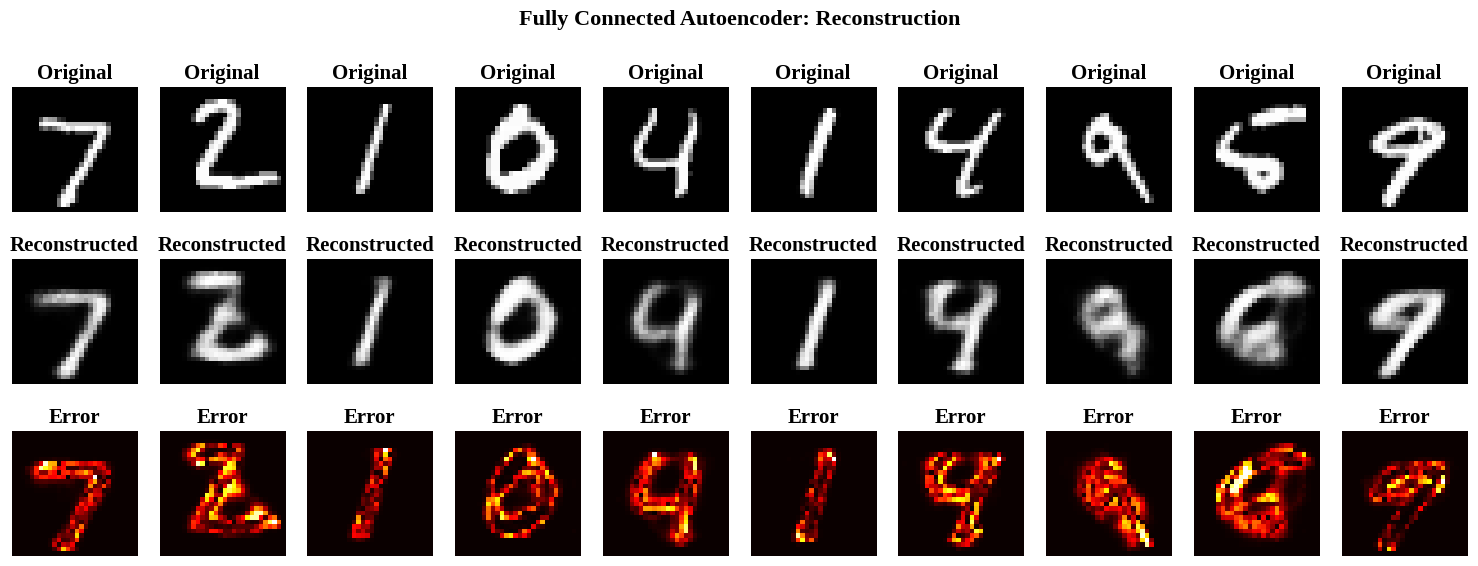

In [ ]:
plot_reconstruction(
    x_test,
    reconstructed_images,
    "Fully Connected Autoencoder",
    "fc_ae_reconstruction",
    n=10
)

# Convolutional Autoencoder

In [ ]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train_cnn.shape)
print("Testing shape:", x_test_cnn.shape)

Training shape: (10000, 28, 28, 1)
Testing shape: (2000, 28, 28, 1)


In [ ]:
conv_autoencoder = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    # Latent feature map
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

conv_autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

conv_autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

In [ ]:
conv_history = conv_autoencoder.fit(
    x_train_cnn,
    x_train_cnn,
    batch_size=128,
    epochs=20,
    validation_data=(x_test_cnn, x_test_cnn)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 339ms/step - loss: 0.1940 - val_loss: 0.0986
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 345ms/step - loss: 0.0914 - val_loss: 0.0858
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 337ms/step - loss: 0.0824 - val_loss: 0.0791
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 337ms/step - loss: 0.0789 - val_loss: 0.0757
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 484ms/step - loss: 0.0768 - val_loss: 0.0742
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 388ms/step - loss: 0.0752 - val_loss: 0.0738
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 338ms/step - loss: 0.0741 - val_loss: 0.0724
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 373ms/step - loss: 0.0733 - val_loss: 0.0714
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 401ms/step - loss: 0.0723 - val_loss: 0.0707
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 344ms/step - loss: 0.0717 - val_loss: 0.0701
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 337ms/step - loss: 0.0713 - val_loss: 0.0696
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27

In [ ]:
conv_reconstructed = conv_autoencoder.predict(
    x_test_cnn
)

print("Reconstructed shape:", conv_reconstructed.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Reconstructed shape: (2000, 28, 28, 1)


In [ ]:
conv_reconstructed_images = conv_reconstructed.squeeze(-1)

print(conv_reconstructed_images.shape)

(2000, 28, 28)


In [ ]:
def plot_reconstruction_comparison(
    original,
    fc_reconstructed,
    cae_reconstructed,
    filename,
    n=10
):

    plt.figure(figsize=(15, 5))

    for i in range(n):

        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i], cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # FC-AE Reconstruction
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(fc_reconstructed[i], cmap="gray")
        plt.title("FC-AE")
        plt.axis("off")

        # CAE Reconstruction
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(cae_reconstructed[i], cmap="gray")
        plt.title("CAE")
        plt.axis("off")

    plt.suptitle(
        "Reconstruction Comparison",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

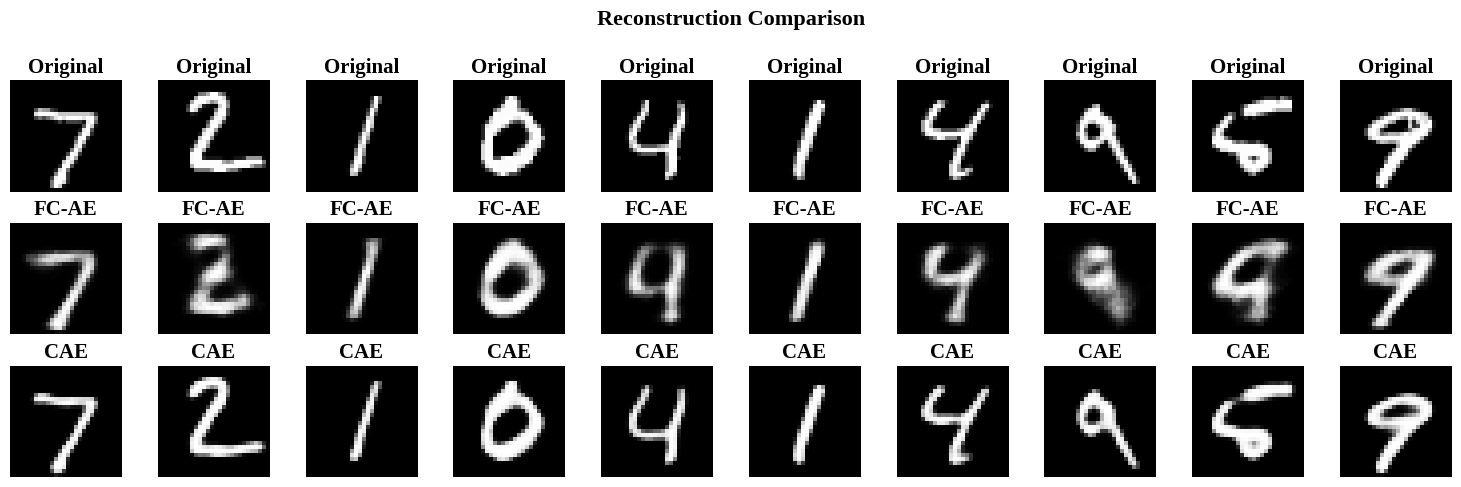

In [ ]:
plot_reconstruction_comparison(
    x_test,
    reconstructed_images,
    conv_reconstructed_images,
    "fc_vs_cae_reconstruction",
    n=10
)

In [ ]:
conv_results = evaluate_reconstruction(
    x_test,
    conv_reconstructed_images
)

Metric              Value
--------------------------
Test MSE            0.002589
Test MAE            0.015037
Mean SSIM           0.973643


In [ ]:
results["Convolutional AE"] = conv_results

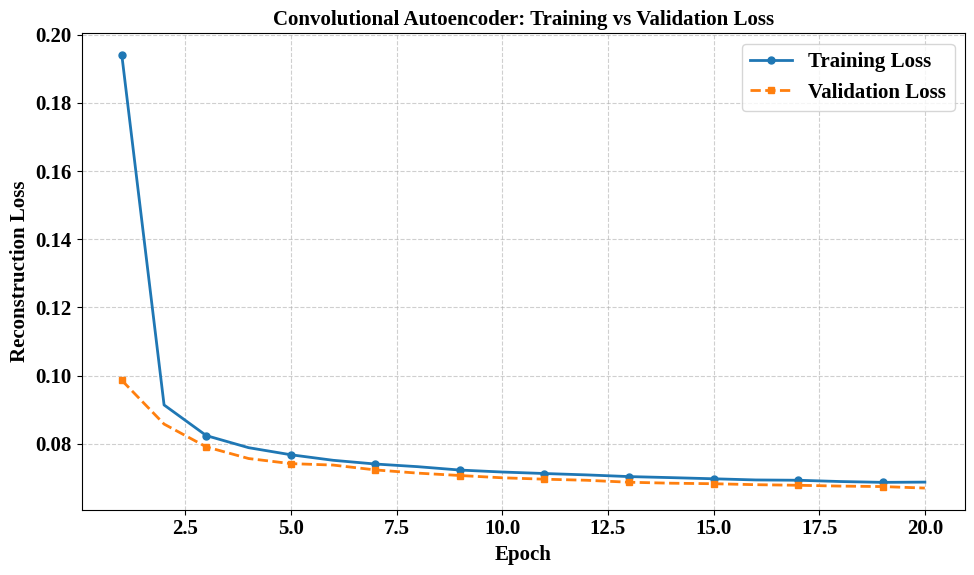

In [ ]:
plot_train_vs_val_loss(
    conv_history,
    "Convolutional Autoencoder",
    "conv_ae_loss"
)

# Denoising Autoencoder

In [ ]:
def add_gaussian_noise(images, sigma):

    noise = np.random.normal(
        loc=0,
        scale=sigma,
        size=images.shape
    )

    noisy_images = images + noise

    # Keep pixels between 0 and 1
    noisy_images = np.clip(noisy_images, 0, 1)

    return noisy_images

In [ ]:
def add_salt_pepper_noise(images, p):

    noisy_images = images.copy()

    random_values = np.random.rand(*images.shape)

    # Salt pixels → 1
    noisy_images[random_values < p / 2] = 1

    # Pepper pixels → 0
    noisy_images[
        (random_values >= p / 2) &
        (random_values < p)
    ] = 0

    return noisy_images

In [ ]:
denoising_autoencoder = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    # Latent representation
    layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        1, (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

denoising_autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
denoising_autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

In [ ]:
x_train_noisy = add_gaussian_noise(
    x_train_cnn,
    sigma=0.2
)

x_test_noisy = add_gaussian_noise(
    x_test_cnn,
    sigma=0.2
)

print("Clean:", x_train_cnn.shape)
print("Noisy:", x_train_noisy.shape)

Clean: (10000, 28, 28, 1)
Noisy: (10000, 28, 28, 1)


In [ ]:
denoising_history = denoising_autoencoder.fit(
    x_train_noisy,
    x_train_cnn,
    batch_size=128,
    epochs=20,
    validation_data=(x_test_noisy, x_test_cnn)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 362ms/step - loss: 0.2478 - val_loss: 0.1182
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 345ms/step - loss: 0.1063 - val_loss: 0.0957
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 347ms/step - loss: 0.0938 - val_loss: 0.0903
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 359ms/step - loss: 0.0893 - val_loss: 0.0859
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 348ms/step - loss: 0.0866 - val_loss: 0.0838
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 346ms/step - loss: 0.0845 - val_loss: 0.0820
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 343ms/step - loss: 0.0829 - val_loss: 0.0807
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 347ms/step - loss: 0.0818 - val_loss: 0.0805
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 28s 351ms/step - loss: 0.0807 - val_loss: 0.0788
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 345ms/step - loss: 0.0799 - val_loss: 0.0778
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 346ms/step - loss: 0.0790 - val_loss: 0.0773
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 41

In [ ]:
denoised = denoising_autoencoder.predict(x_test_noisy)

denoised_images = denoised.squeeze()

print("Denoised shape:", denoised_images.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Denoised shape: (2000, 28, 28)


In [ ]:
def plot_denoising_comparison(
    clean,
    noisy,
    denoised,
    filename,
    n=10
):

    plt.figure(figsize=(15, 5))

    for i in range(n):

        # Clean
        plt.subplot(3, n, i + 1)
        plt.imshow(clean[i], cmap="gray")
        plt.title("Clean")
        plt.axis("off")

        # Noisy
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i], cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        # Denoised
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(denoised[i], cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

    plt.suptitle(
        "Denoising Autoencoder: Clean vs Noisy vs Denoised",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

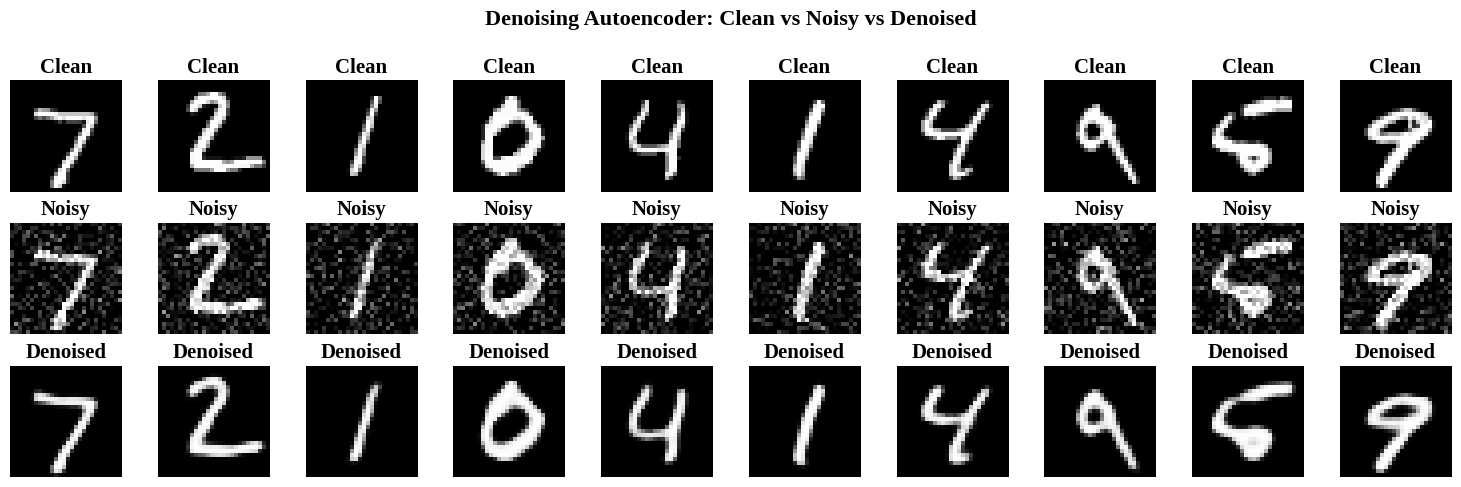

In [ ]:
plot_denoising_comparison(
    x_test,
    x_test_noisy.squeeze(),
    denoised_images,
    "denoising_comparison",
    n=10
)

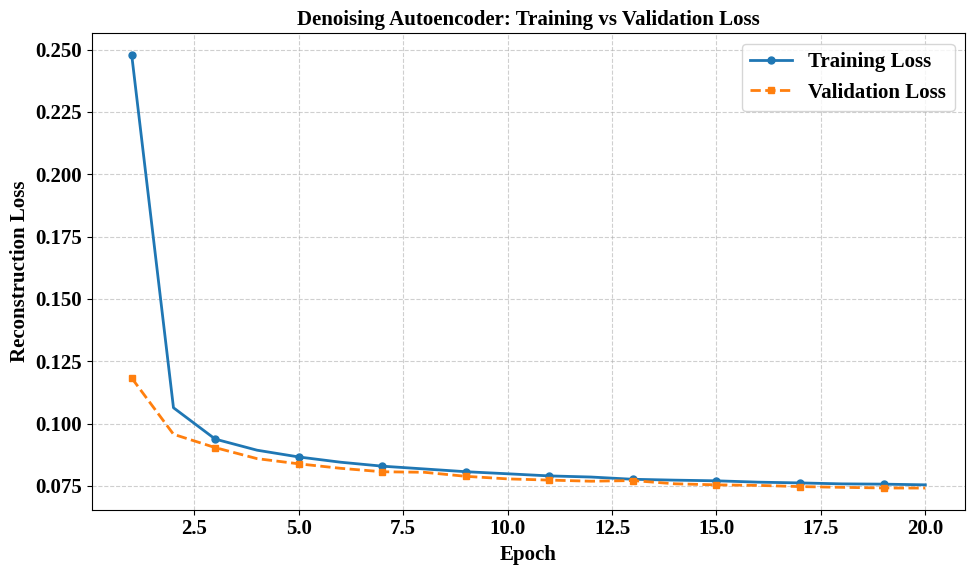

In [ ]:
plot_train_vs_val_loss(
    denoising_history,
    "Denoising Autoencoder",
    "denoising_ae_loss"
)

In [ ]:
denoising_results = evaluate_reconstruction(
    x_test,
    denoised_images,
)

results["Denoising AE"] = denoising_results

Metric              Value
--------------------------
Test MSE            0.004679
Test MAE            0.021278
Mean SSIM           0.944660


In [ ]:
def evaluate_noise_levels(
    model,
    clean_images,
    noise_levels
):

    rows = []

    for sigma in noise_levels:

        # Add noise
        noisy = add_gaussian_noise(
            clean_images,
            sigma
        )

        # Denoise
        reconstructed = model.predict(
            noisy,
            verbose=0
        ).squeeze()

        # Calculate metrics
        print(f"\nNoise:{sigma}")
        metrics = evaluate_reconstruction(
            clean_images.squeeze(),
            reconstructed
        )

        rows.append({
            "Noise Level": sigma,
            "MSE": metrics["MSE"],
            "MAE": metrics["MAE"],
            "SSIM": metrics["SSIM"]
        })

    return pd.DataFrame(rows)

In [ ]:
noise_levels = [0.1, 0.2, 0.3]

noise_results = evaluate_noise_levels(
    denoising_autoencoder,
    x_test_cnn,
    noise_levels
)

print()
noise_results


Noise:0.1
Metric              Value
--------------------------
Test MSE            0.003766
Test MAE            0.018101
Mean SSIM           0.959378

Noise:0.2
Metric              Value
--------------------------
Test MSE            0.004668
Test MAE            0.021268
Mean SSIM           0.944897

Noise:0.3
Metric              Value
--------------------------
Test MSE            0.007008
Test MAE            0.029014
Mean SSIM           0.872354



,Noise Level,MSE,MAE,SSIM
0,0.1,0.003766,0.018101,0.959378
1,0.2,0.004668,0.021268,0.944897
2,0.3,0.007008,0.029014,0.872354


In [ ]:
def plot_noise_quality(
    results_df,
    filename
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["Noise Level"],
        results_df["MSE"],
        marker="o",
        label="MSE"
    )

    plt.plot(
        results_df["Noise Level"],
        results_df["MAE"],
        marker="s",
        label="MAE"
    )

    plt.xlabel("Noise Level (σ)")
    plt.ylabel("Error")
    plt.title("Noise Level vs Reconstruction Error")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

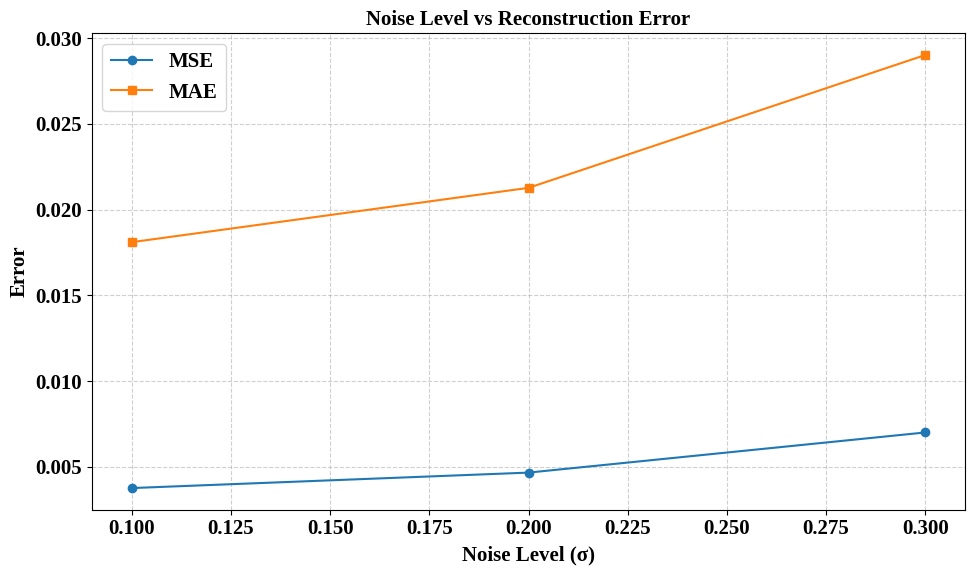

In [ ]:
plot_noise_quality(
    noise_results,
    "noise_vs_reconstruction_quality"
)

# Variational Autoencoders

In [ ]:
latent_dim = 2

encoder_input = layers.Input(shape=(28, 28, 1))

x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    padding="same"
)(encoder_input)

x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation="relu")(x)

mu = layers.Dense(latent_dim, name="mu")(x)

log_var = layers.Dense(
    latent_dim,
    name="log_var"
)(x)

In [ ]:
def sample_latent(args):

    mu, log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(mu)
    )

    sigma = tf.exp(0.5 * log_var)

    return mu + sigma * epsilon

In [ ]:
z = layers.Lambda(
    sample_latent,
    name="z"
)([mu, log_var])

In [ ]:
encoder = models.Model(
    encoder_input,
    [mu, log_var, z],
    name="VAE_Encoder"
)

encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder_input = layers.Input(
    shape=(latent_dim,)
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(decoder_input)

x = layers.Reshape((7, 7, 64))(x)

x = layers.Conv2DTranspose(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2DTranspose(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

decoder_output = layers.Conv2DTranspose(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

decoder = models.Model(
    decoder_input,
    decoder_output,
    name="VAE_Decoder"
)

decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
vae_output = decoder(z)

vae = models.Model(
    encoder_input,
    vae_output,
    name="VAE"
)

vae.summary()

Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        258 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ VAE_Decoder         │ (None, 28, 28, 1) │     65,089 │ z[0][0]           │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 485,957 (1.85 MB)

 Trainable params: 485,957 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(models.Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = tf.keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            mu, log_var, z = self.encoder(data)

            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var
                    - tf.square(mu)
                    - tf.exp(log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss +
                kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        mu, log_var, z = self.encoder(data)

        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + log_var
                - tf.square(mu)
                - tf.exp(log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "total_loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [ ]:
vae_model = VAE(
    encoder,
    decoder
)

vae_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    )
)

In [ ]:
vae_history = vae_model.fit(
    x_train_cnn,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_cnn,)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 296ms/step - kl_loss: 4.5117 - reconstruction_loss: 262.0046 - total_loss: 266.5163 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - kl_loss: 3.9968 - reconstruction_loss: 189.8416 - total_loss: 193.8385 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 42s 277ms/step - kl_loss: 4.7009 - reconstruction_loss: 174.0369 - total_loss: 178.7378 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - kl_loss: 4.8253 - reconstruction_loss: 167.5150 - total_loss: 172.3404 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 277ms/step - kl_loss: 4.9597 - reconstruction_loss: 163.7092 - total_loss: 168.668

In [ ]:
mu_test, log_var_test, z_test = encoder.predict(
    x_test_cnn
)

vae_reconstructed = decoder.predict(
    z_test
)

vae_reconstructed_images = vae_reconstructed.squeeze()

print(vae_reconstructed_images.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
(2000, 28, 28)


In [ ]:
vae_image_metrics = evaluate_reconstruction(
    x_test,
    vae_reconstructed_images,
)

Metric              Value
--------------------------
Test MSE            0.042663
Test MAE            0.099256
Mean SSIM           0.500027


In [ ]:
vae_test_results = vae_model.evaluate(
    x_test_cnn,
    return_dict=True
)

print("Reconstruction Loss:",
      vae_test_results["reconstruction_loss"])

print("KL Loss:",
      vae_test_results["kl_loss"])

print("Total Loss:",
      vae_test_results["total_loss"])

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - kl_loss: 0.0000e+00 - reconstruction_loss: 0.0000e+00 - total_loss: 0.0000e+00
Reconstruction Loss: 0.0
KL Loss: 0.0
Total Loss: 0.0


In [ ]:
def plot_latent_space(
    z,
    labels,
    filename
):

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=labels,
        cmap="tab10",
        s=10,
        alpha=0.7
    )

    plt.xlabel("z1")
    plt.ylabel("z2")

    plt.title(
        "VAE Latent Space"
    )

    plt.colorbar(
        scatter,
        label="Digit Label"
    )

    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

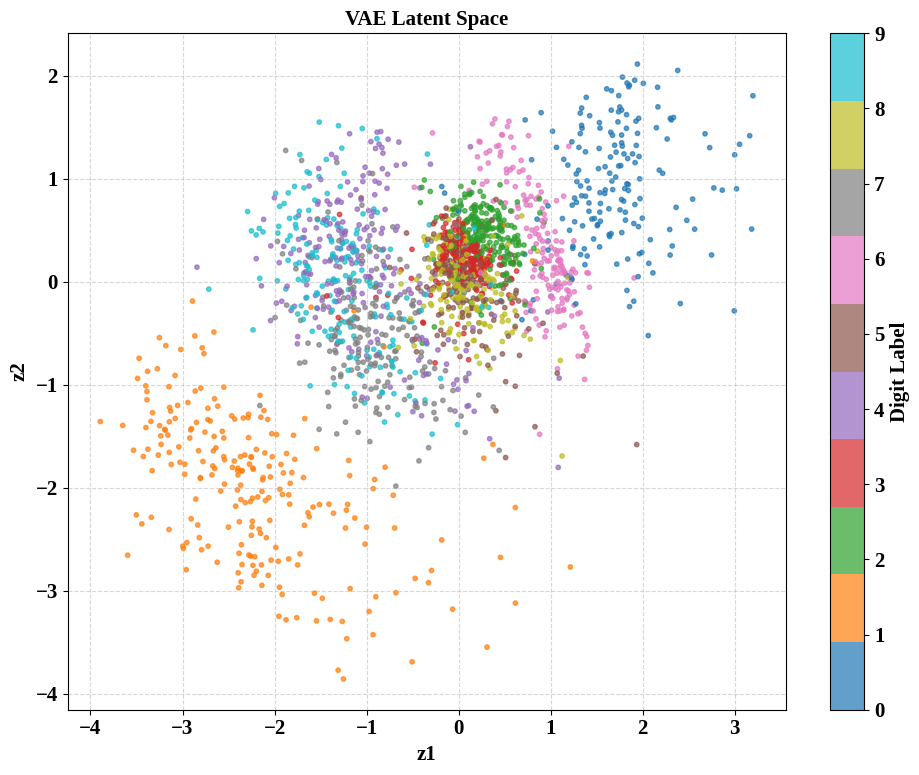

In [ ]:
plot_latent_space(
    z_test,
    y_test[:2000],
    "vae_latent_space"
)

In [ ]:
def generate_images(
    decoder,
    n=25
):

    random_z = np.random.normal(
        size=(n, 2)
    )

    generated = decoder.predict(
        random_z,
        verbose=0
    )

    return generated.squeeze()

In [ ]:
generated_images = generate_images(
    decoder,
    n=25
)

In [ ]:
def plot_generated_images(
    images,
    filename,
    n=25
):

    grid_size = int(np.sqrt(n))

    plt.figure(figsize=(10, 10))

    for i in range(n):

        plt.subplot(
            grid_size,
            grid_size,
            i + 1
        )

        plt.imshow(
            images[i],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        "VAE Randomly Generated Images",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

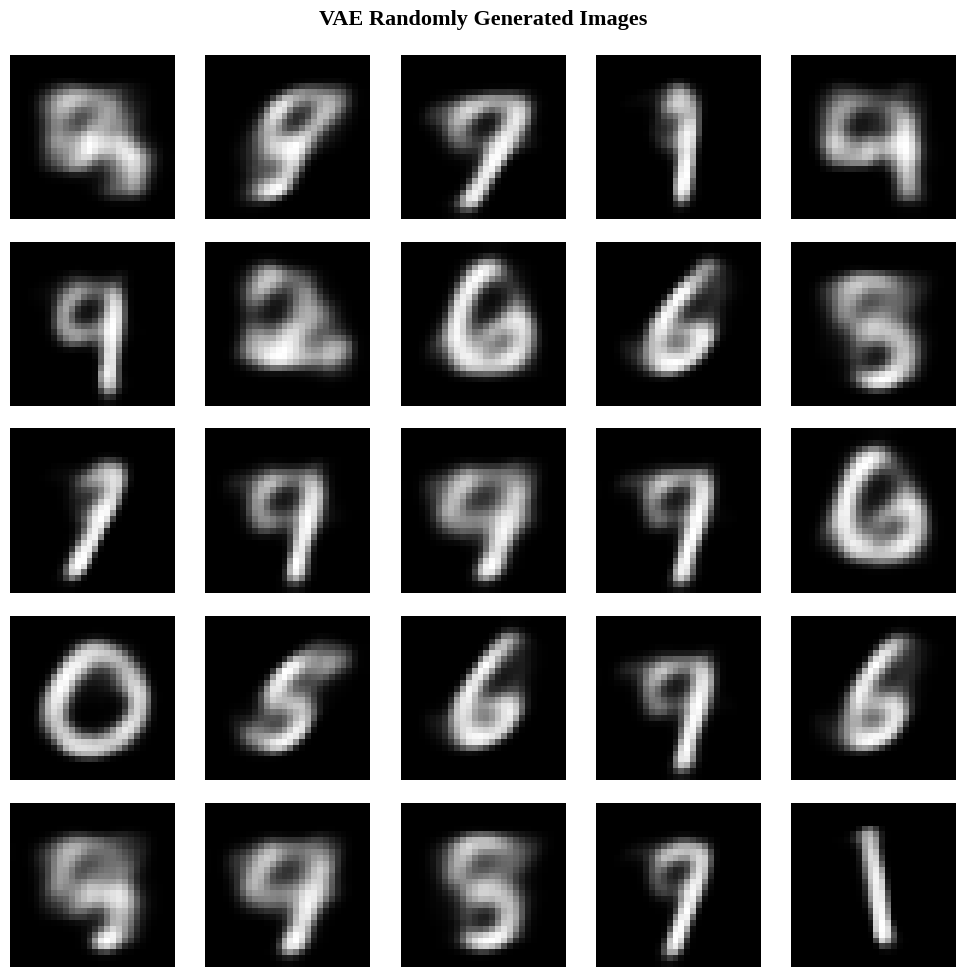

In [ ]:
plot_generated_images(
    generated_images,
    "vae_generated_images"
)

In [ ]:
zA = z_test[0]
zB = z_test[1]

In [ ]:
def interpolate_latent(
    zA,
    zB,
    steps=11
):

    alphas = np.linspace(
        0,
        1,
        steps
    )

    interpolated = []

    for alpha in alphas:

        z = (
            (1 - alpha) * zA
            + alpha * zB
        )

        interpolated.append(z)

    return np.array(interpolated)

In [ ]:
interpolated_z = interpolate_latent(
    zA,
    zB
)

In [ ]:
interpolated_images = decoder.predict(
    interpolated_z,
    verbose=0
).squeeze()

In [ ]:
def plot_interpolation(
    images,
    filename
):

    n = len(images)

    plt.figure(figsize=(15, 3))

    for i in range(n):

        plt.subplot(1, n, i + 1)

        plt.imshow(
            images[i],
            cmap="gray"
        )

        plt.title(
            f"α={i/10:.1f}"
        )

        plt.axis("off")

    plt.suptitle(
        "VAE Latent Space Interpolation",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

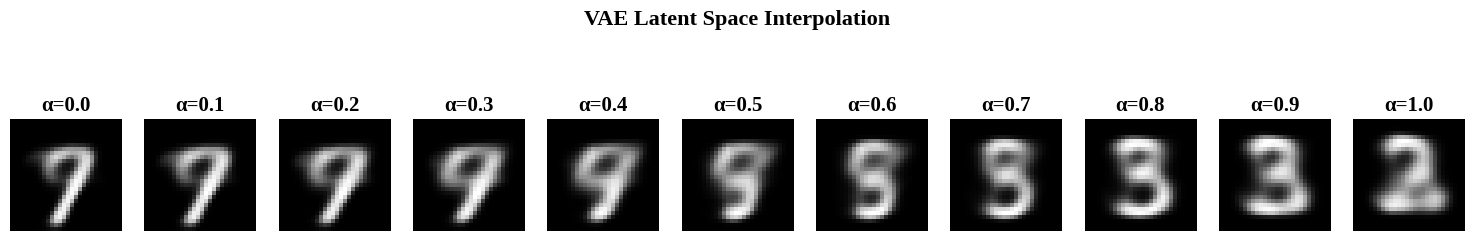

In [ ]:
plot_interpolation(
    interpolated_images,
    "vae_interpolation"
)

In [ ]:
def plot_vae_reconstruction_loss(
    history,
    filename
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        history.history["reconstruction_loss"],
        label="Training Reconstruction Loss",
        linewidth=2
    )

    plt.plot(
        history.history["val_reconstruction_loss"],
        label="Validation Reconstruction Loss",
        linewidth=2,
        linestyle="--"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction Loss")

    plt.title(
        "VAE Training vs Validation Reconstruction Loss"
    )

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

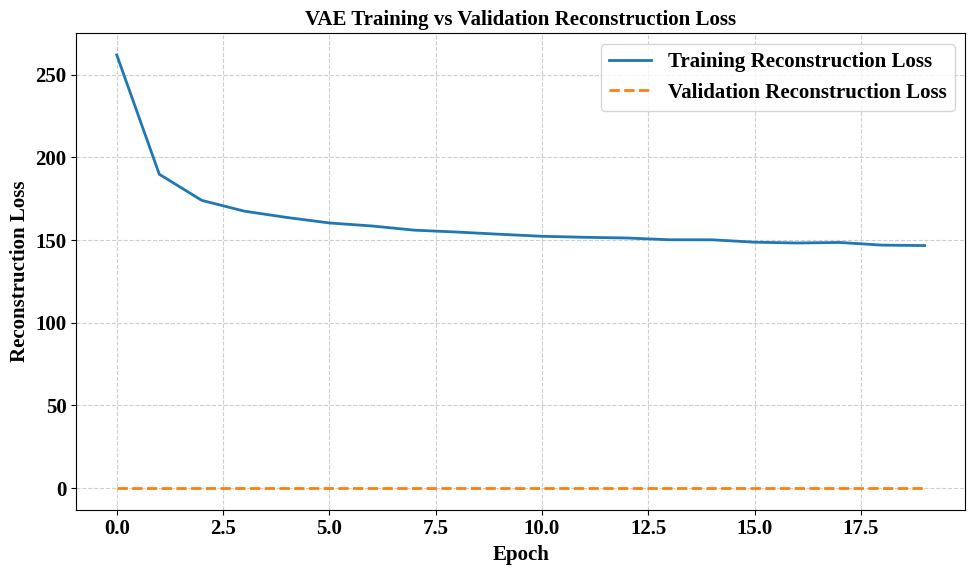

In [ ]:
plot_vae_reconstruction_loss(
    vae_history,
    "vae_reconstruction_loss"
)

# Reconstruction Error Distribution

In [ ]:
def calculate_reconstruction_errors(
    original,
    reconstructed
):

    errors = np.mean(
        (original - reconstructed) ** 2,
        axis=(1, 2)
    )

    return errors

In [ ]:
reconstruction_errors = calculate_reconstruction_errors(
    x_test,
    reconstructed_images
)

print("Number of errors:", len(reconstruction_errors))
print("Minimum error:", reconstruction_errors.min())
print("Maximum error:", reconstruction_errors.max())
print("Mean error:", reconstruction_errors.mean())

Number of errors: 2000
Minimum error: 0.0019565248
Maximum error: 0.08305344
Mean error: 0.022779455


In [ ]:
def plot_error_distribution(
    errors,
    filename
):

    plt.figure(figsize=(10, 6))

    plt.hist(
        errors,
        bins=50,
        edgecolor="black"
    )

    plt.xlabel("Reconstruction Error (MSE)")
    plt.ylabel("Number of Images")

    plt.title(
        "Distribution of Reconstruction Errors"
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

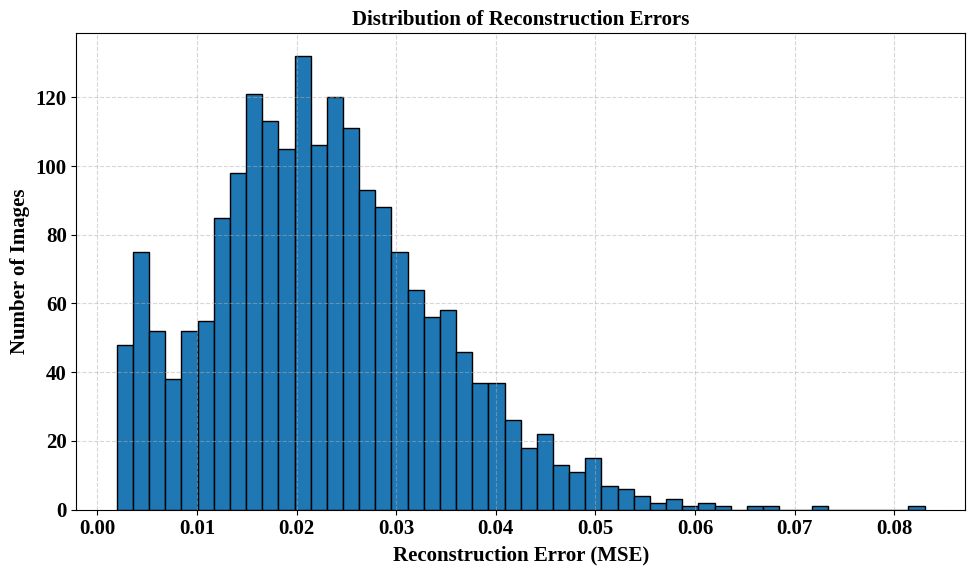

In [ ]:
plot_error_distribution(
    reconstruction_errors,
    "reconstruction_error_distribution"
)

In [ ]:
high_error_indices = np.argsort(
    reconstruction_errors
)[-5:][::-1]

print("High-error image indices:")
print(high_error_indices)

print("\nTheir errors:")
print(reconstruction_errors[high_error_indices])

High-error image indices:
[1790 1782 1170 1017  654]

Their errors:
[0.08305344 0.07218497 0.0670962  0.06574979 0.06279103]


In [ ]:
def plot_high_error_images(
    original,
    reconstructed,
    errors,
    indices,
    filename
):

    plt.figure(figsize=(10, 10))

    for row, idx in enumerate(indices):

        # Original
        plt.subplot(5, 2, 2 * row + 1)

        plt.imshow(
            original[idx],
            cmap="gray"
        )

        plt.title(
            f"Sample {row + 1} - Original"
        )

        plt.axis("off")

        # Reconstruction
        plt.subplot(5, 2, 2 * row + 2)

        plt.imshow(
            reconstructed[idx],
            cmap="gray"
        )

        plt.title(
            f"Reconstruction | Error = {errors[idx]:.5f}"
        )

        plt.axis("off")

    plt.suptitle(
        "Five Highest Reconstruction-Error Images",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

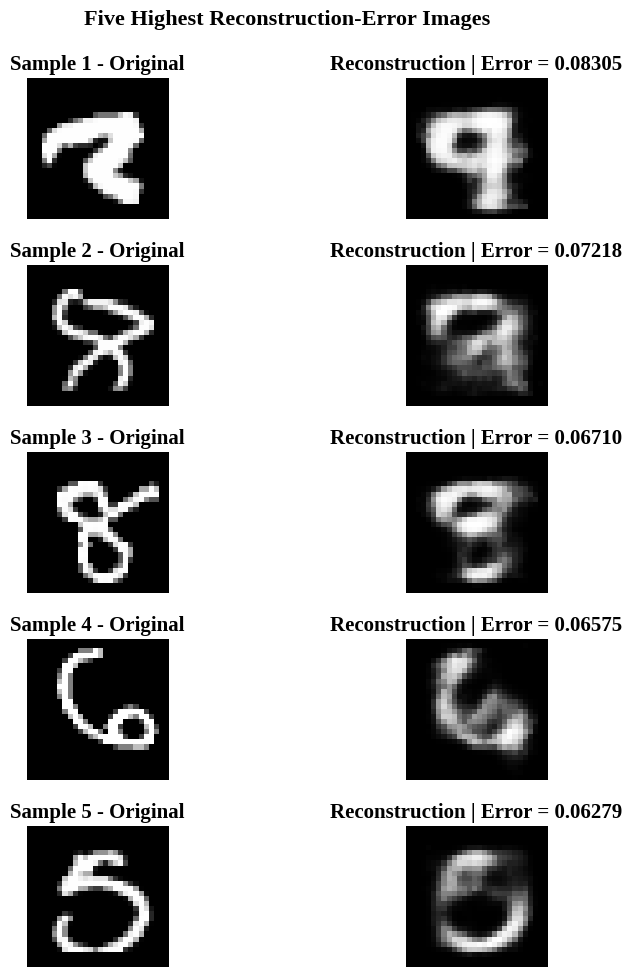

In [ ]:
plot_high_error_images(
    x_test,
    reconstructed_images,
    reconstruction_errors,
    high_error_indices,
    "high_error_images"
)

In [ ]:
def plot_noise_metrics(results_df, filename_prefix):

    # MSE
    plt.figure(figsize=(10, 6))
    plt.plot(
        results_df["Noise Level"],
        results_df["MSE"],
        marker="o",
        linewidth=2
    )
    plt.xlabel("Noise Level (σ)")
    plt.ylabel("MSE")
    plt.title("Noise Level vs MSE")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_mse.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    # MAE
    plt.figure(figsize=(10, 6))
    plt.plot(
        results_df["Noise Level"],
        results_df["MAE"],
        marker="o",
        linewidth=2
    )
    plt.xlabel("Noise Level (σ)")
    plt.ylabel("MAE")
    plt.title("Noise Level vs MAE")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_mae.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    # SSIM
    plt.figure(figsize=(10, 6))
    plt.plot(
        results_df["Noise Level"],
        results_df["SSIM"],
        marker="o",
        linewidth=2
    )
    plt.xlabel("Noise Level (σ)")
    plt.ylabel("SSIM")
    plt.title("Noise Level vs SSIM")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{filename_prefix}_ssim.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

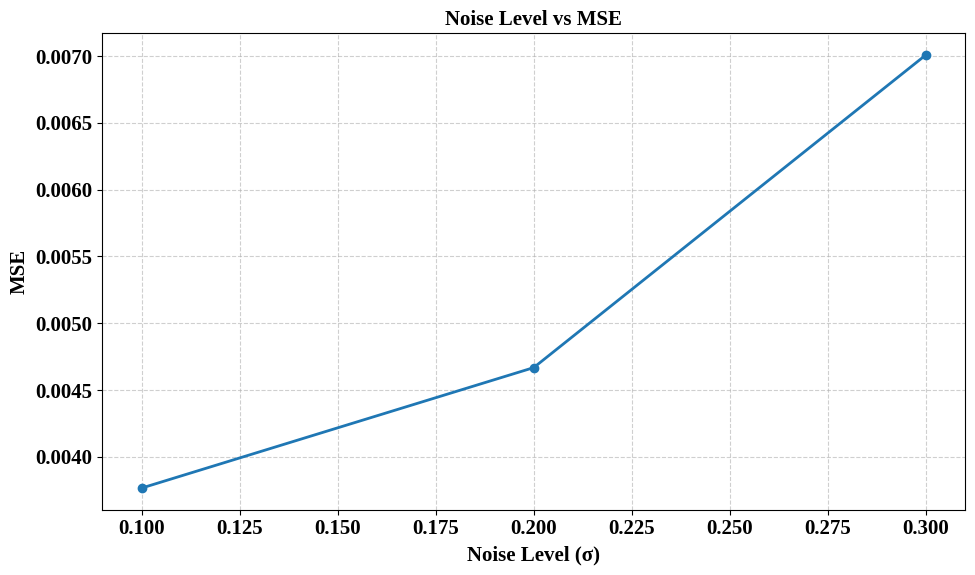

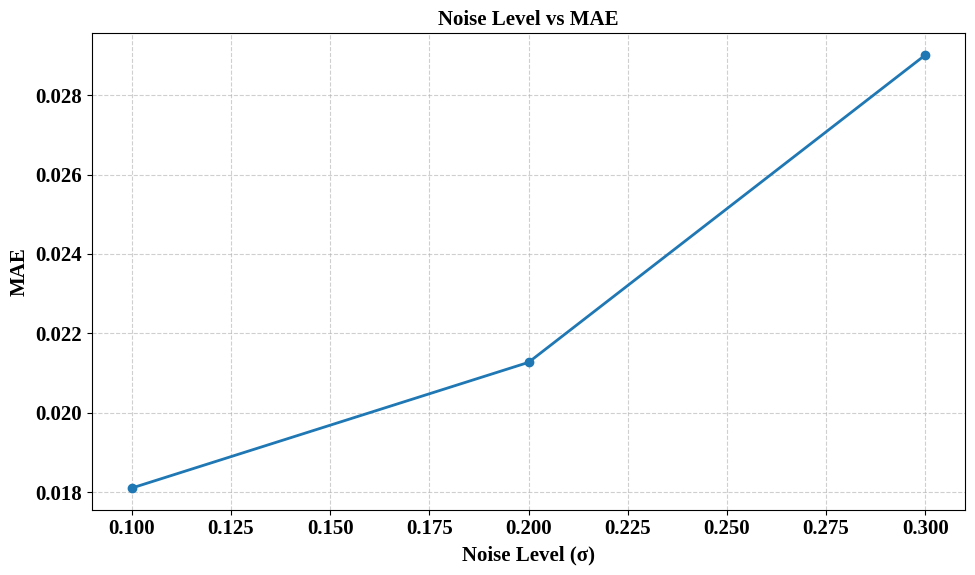

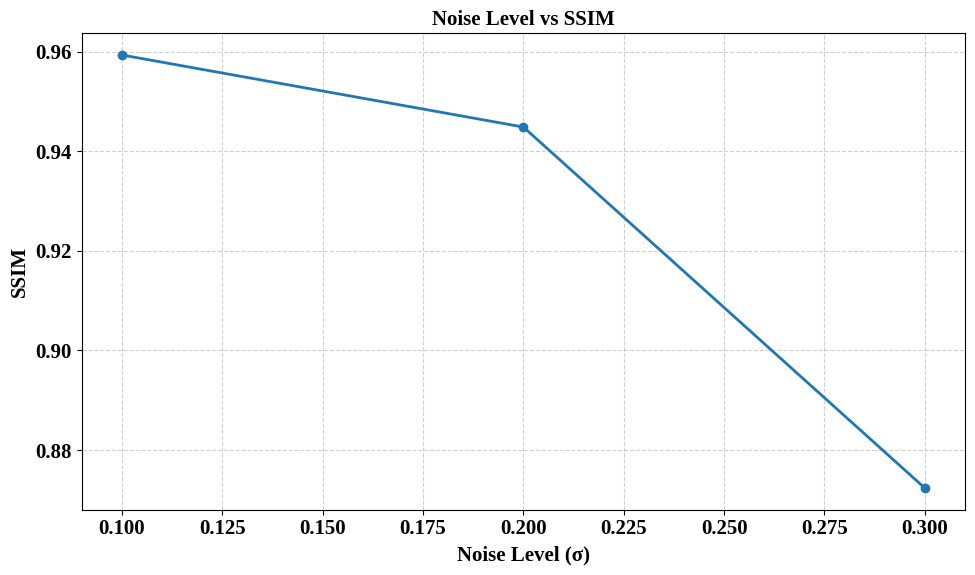

In [ ]:
plot_noise_metrics(
    noise_results,
    "noise_level"
)

# Additional Latent-Dimension Study

In [ ]:
def build_fc_autoencoder(latent_dim):

    model = models.Sequential([
        layers.Input(shape=(784,)),

        layers.Dense(128, activation="relu"),
        layers.Dense(32, activation="relu"),

        # Latent layer
        layers.Dense(
            latent_dim,
            activation="relu"
        ),

        layers.Dense(32, activation="relu"),
        layers.Dense(128, activation="relu"),

        layers.Dense(
            784,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy"
    )

    return model

In [ ]:
def evaluate_latent_dimension(
    latent_dim,
    epochs=20
):

    print(f"\nTraining latent dimension = {latent_dim}")

    # Build model
    model = build_fc_autoencoder(
        latent_dim
    )

    # Train
    model.fit(
        x_train_flat,
        x_train_flat,
        batch_size=128,
        epochs=epochs,
        validation_data=(
            x_test_flat,
            x_test_flat
        ),
        verbose=0
    )

    # Reconstruct test images
    reconstructed = model.predict(
        x_test_flat,
        verbose=0
    )

    reconstructed_images = reconstructed.reshape(
        -1, 28, 28
    )

    # Calculate MSE and SSIM
    metrics = evaluate_reconstruction(
        x_test,
        reconstructed_images
    )

    # Parameter count
    parameters = model.count_params()

    return {
        "Latent Dimension": latent_dim,
        "MSE": metrics["MSE"],
        "SSIM": metrics["SSIM"],
        "Parameters": parameters
    }

In [ ]:
latent_dimensions = [2, 8, 16, 32]

latent_results = []

for dim in latent_dimensions:

    result = evaluate_latent_dimension(
        dim,
        epochs=20
    )

    latent_results.append(result)


Training latent dimension = 2
Metric              Value
--------------------------
Test MSE            0.046838
Test MAE            0.110398
Mean SSIM           0.434463

Training latent dimension = 8
Metric              Value
--------------------------
Test MSE            0.028525
Test MAE            0.070871
Mean SSIM           0.665247

Training latent dimension = 16
Metric              Value
--------------------------
Test MSE            0.021986
Test MAE            0.058310
Mean SSIM           0.738112

Training latent dimension = 32
Metric              Value
--------------------------
Test MSE            0.018799
Test MAE            0.051917
Mean SSIM           0.771977


In [ ]:
latent_df = pd.DataFrame(
    latent_results
)

print(latent_df.to_string(index=False))

 Latent Dimension      MSE     SSIM  Parameters
                2 0.046838 0.434463      210130
                8 0.028525 0.665247      210520
               16 0.021986 0.738112      211040
               32 0.018799 0.771977      212080


In [ ]:
def plot_latent_vs_mse(
    results_df,
    filename
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["Latent Dimension"],
        results_df["MSE"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Latent Dimension")
    plt.ylabel("Reconstruction MSE")

    plt.title(
        "Latent Dimension vs Reconstruction MSE"
    )

    plt.xticks(
        results_df["Latent Dimension"]
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )

    plt.tight_layout()

    plt.savefig(
        f"{filename}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

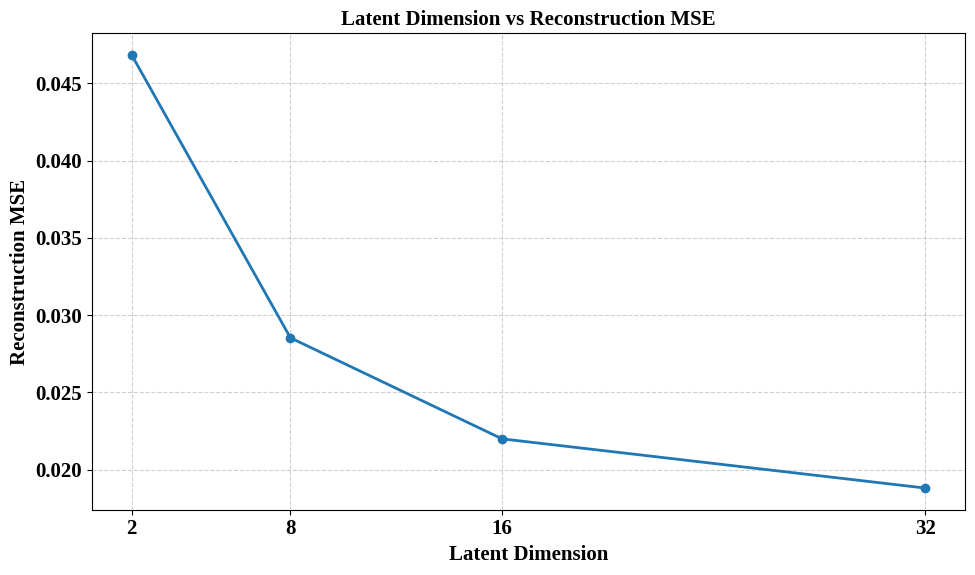

In [ ]:
plot_latent_vs_mse(
    latent_df,
    "latent_dimension_vs_mse"
)